# CNN Multi-Class Classification: Spike vs Exc Solder vs Poor Solder

This notebook implements a simple Convolutional Neural Network (CNN) to classify images as 'spike', 'exc_solder', or 'poor_solder' based on the filename labels from the WIN_20220330 dataset.

## 1. Import Required Libraries

Import necessary libraries including TensorFlow/Keras, OpenCV, NumPy, Matplotlib, and other data processing libraries.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow version: 2.18.0
Libraries imported successfully!


## 2. Data Preparation and Loading

Load images from the dataset folder, filter for WIN_20220330 files, extract labels from filenames (spike/exc_solder/poor_solder), and organize the data.

In [2]:
# Define dataset path
dataset_path = r'C:\Users\david\Desktop\project\dataset\Labeled_Crop'

# Get all image files starting with WIN_20220330
image_files = glob.glob(os.path.join(dataset_path, 'WIN_20220330*.jpg'))

print(f"Found {len(image_files)} images starting with WIN_20220330")

# Extract labels from filenames
def extract_label_from_filename(filename):
    """Extract label from filename based on 'spike', 'exc_solder', or 'poor_solder' in the name"""
    basename = os.path.basename(filename)
    if '_spike_' in basename:
        return 'spike'
    elif '_exc_solder_' in basename:
        return 'exc_solder'
    elif '_poor_solder_' in basename:
        return 'poor_solder'
    else:
        return 'unknown'

# Create DataFrame with image paths and labels
data = []
for img_path in image_files:
    label = extract_label_from_filename(img_path)
    if label != 'unknown':  # Only include files with clear labels
        data.append({'image_path': img_path, 'label': label})

df = pd.DataFrame(data)

print(f"\nDataset Summary:")
print(f"Total images with valid labels: {len(df)}")
print(f"\nClass distribution:")
print(df['label'].value_counts())

# Display first few entries
print(f"\nFirst 5 entries:")
print(df.head())

Found 252 images starting with WIN_20220330

Dataset Summary:
Total images with valid labels: 210

Class distribution:
label
spike          91
exc_solder     76
poor_solder    43
Name: count, dtype: int64

First 5 entries:
                                          image_path        label
0  C:\Users\david\Desktop\project\dataset\Labeled...   exc_solder
1  C:\Users\david\Desktop\project\dataset\Labeled...   exc_solder
2  C:\Users\david\Desktop\project\dataset\Labeled...        spike
3  C:\Users\david\Desktop\project\dataset\Labeled...  poor_solder
4  C:\Users\david\Desktop\project\dataset\Labeled...        spike


## 3. Data Preprocessing and Augmentation

Resize images to uniform dimensions, normalize pixel values, apply data augmentation techniques, and convert labels to categorical format.

In [3]:
# Define image parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3

def load_and_preprocess_image(image_path):
    """Load and preprocess a single image"""
    # Load image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Warning: Could not load image {image_path}")
        return None
    
    # Convert BGR to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Resize image
    image = cv2.resize(image, (IMG_WIDTH, IMG_HEIGHT))
    
    # Normalize pixel values to [0, 1]
    image = image.astype(np.float32) / 255.0
    
    return image

# Load all images
print("Loading and preprocessing images...")
images = []
labels = []
failed_images = []

for idx, row in df.iterrows():
    img = load_and_preprocess_image(row['image_path'])
    if img is not None:
        images.append(img)
        labels.append(row['label'])
    else:
        failed_images.append(row['image_path'])

print(f"Successfully loaded {len(images)} images")
if failed_images:
    print(f"Failed to load {len(failed_images)} images")

# Convert to numpy arrays
X = np.array(images)
y = np.array(labels)

print(f"\nImage array shape: {X.shape}")
print(f"Labels shape: {y.shape}")

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded, num_classes=3)  # Changed from 2 to 3

print(f"\nLabel mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{i}: {class_name}")

print(f"\nEncoded labels shape: {y_categorical.shape}")

Loading and preprocessing images...
Successfully loaded 210 images

Image array shape: (210, 224, 224, 3)
Labels shape: (210,)

Label mapping:
0: exc_solder
1: poor_solder
2: spike

Encoded labels shape: (210, 3)
Successfully loaded 210 images

Image array shape: (210, 224, 224, 3)
Labels shape: (210,)

Label mapping:
0: exc_solder
1: poor_solder
2: spike

Encoded labels shape: (210, 3)


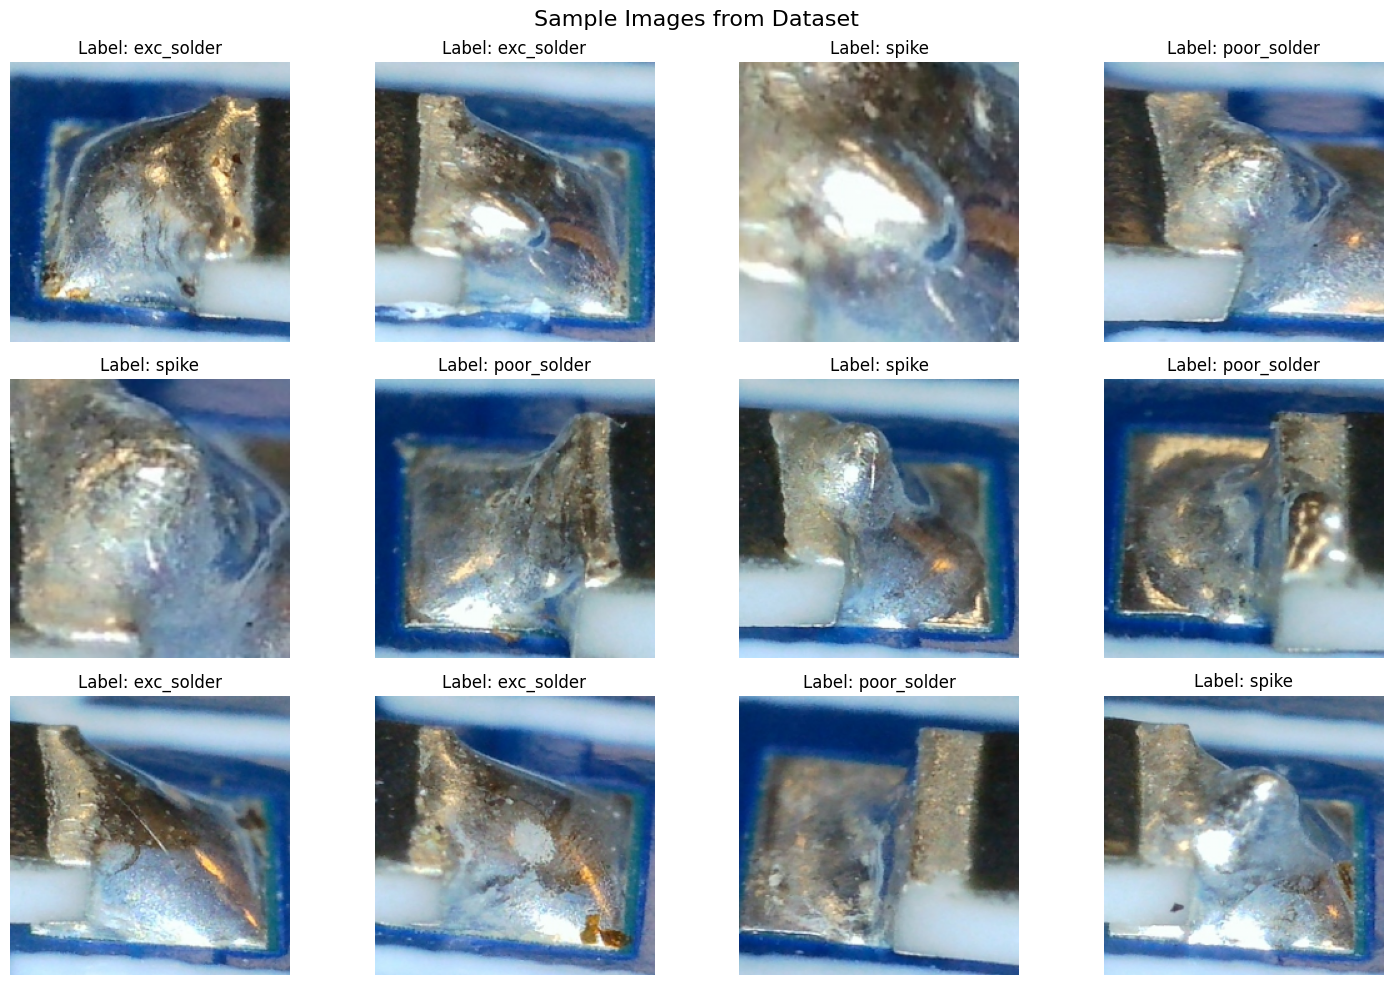

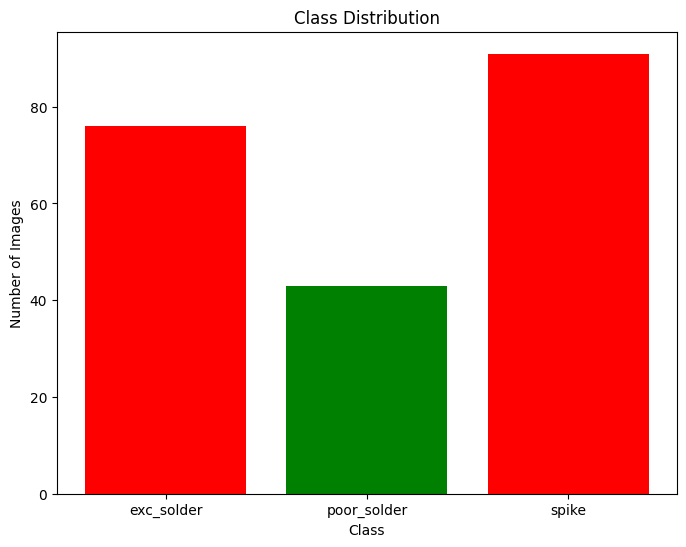

In [4]:
# Visualize some sample images
plt.figure(figsize=(15, 10))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X[i])
    plt.title(f'Label: {y[i]}')
    plt.axis('off')

plt.suptitle('Sample Images from Dataset', fontsize=16)
plt.tight_layout()
plt.show()

# Plot class distribution
unique, counts = np.unique(y, return_counts=True)
plt.figure(figsize=(8, 6))
plt.bar(unique, counts, color=['red', 'green'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.show()

## 4. Train-Test Split

Split the dataset into training and validation sets using stratified sampling to maintain class balance.

In [5]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test labels shape: {y_test.shape}")

# Check class distribution in train and test sets
train_class_dist = np.argmax(y_train, axis=1)
test_class_dist = np.argmax(y_test, axis=1)

print(f"\nTraining set class distribution:")
unique, counts = np.unique(train_class_dist, return_counts=True)
for i, (class_idx, count) in enumerate(zip(unique, counts)):
    print(f"{label_encoder.classes_[class_idx]}: {count} ({count/len(train_class_dist)*100:.1f}%)")

print(f"\nTest set class distribution:")
unique, counts = np.unique(test_class_dist, return_counts=True)
for i, (class_idx, count) in enumerate(zip(unique, counts)):
    print(f"{label_encoder.classes_[class_idx]}: {count} ({count/len(test_class_dist)*100:.1f}%)")

# Calculate class weights to handle imbalanced data
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_class_dist),
    y=train_class_dist
)

class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
print(f"\nCalculated class weights: {class_weight_dict}")

# Calculate sample weights for each training sample
sample_weights = np.array([class_weights[label] for label in train_class_dist])
print(f"Sample weights shape: {sample_weights.shape}")

Training set shape: (168, 224, 224, 3)
Test set shape: (42, 224, 224, 3)
Training labels shape: (168, 3)
Test labels shape: (42, 3)

Training set class distribution:
exc_solder: 61 (36.3%)
poor_solder: 34 (20.2%)
spike: 73 (43.5%)

Test set class distribution:
exc_solder: 15 (35.7%)
poor_solder: 9 (21.4%)
spike: 18 (42.9%)

Calculated class weights: {0: 0.9180327868852459, 1: 1.6470588235294117, 2: 0.7671232876712328}
Sample weights shape: (168,)


## 5. Build CNN Model Architecture

Create a simple CNN model with convolutional layers, pooling layers, dropout for regularization, and dense layers for multi-class classification.

In [6]:
def create_cnn_model(input_shape, num_classes):
    """Create a simple CNN model optimized for small datasets with multi-class classification"""
    
    model = Sequential([
        # Simple but effective architecture
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding='same'),
        MaxPooling2D(2, 2),
        Dropout(0.2),
        
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Dropout(0.2),
        
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Dropout(0.3),
        
        # Use Flatten for better feature learning with small datasets
        Flatten(),
        
        # Simple dense layers
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])
    
    return model

# Create the model
input_shape = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
num_classes = 3  # spike, exc_solder, poor_solder

model = create_cnn_model(input_shape, num_classes)

# Display model architecture
model.summary()

print("Optimized CNN model architecture created for small dataset classification.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,816,899 (98.48 MB)

 Trainable params: 25,816,899 (98.48 MB)

 Non-trainable params: 0 (0.00 B)

Optimized CNN model architecture created for small dataset classification.


## 6. Model Training and Evaluation

Compile and train the optimized CNN model with appropriate settings for the multi-class classification task.

In [7]:
# Import required metrics
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import ModelCheckpoint

# Implement Focal Loss for handling class imbalance
def focal_loss(gamma=1.5, alpha=0.3):
    """
    Focal Loss implementation for multi-class classification
    Optimized parameters for small datasets
    """
    def focal_loss_fixed(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        
        # Compute cross entropy
        ce = -y_true * tf.math.log(y_pred)
        
        # Compute p_t
        p_t = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        
        # Compute alpha_t
        alpha_factor = tf.ones_like(y_true) * alpha
        alpha_t = tf.where(tf.equal(y_true, 1), alpha_factor, 1 - alpha_factor)
        
        # Compute focal weight
        focal_weight = alpha_t * tf.pow((1 - p_t), gamma)
        
        # Compute focal loss
        focal_loss = focal_weight * ce
        
        return tf.reduce_mean(tf.reduce_sum(focal_loss, axis=1))
    
    return focal_loss_fixed

# Create focal loss model for comparison
model_focal = create_cnn_model(input_shape, num_classes)

# Compile both models with optimized settings
model.compile(
    optimizer=Adam(learning_rate=0.0005),  # Lower learning rate for stability
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

model_focal.compile(
    optimizer=Adam(learning_rate=0.0005),  # Lower learning rate for stability
    loss=focal_loss(gamma=1.5, alpha=0.3),  # Optimized focal loss parameters
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

print("Models compiled with optimized settings for small dataset classification.")

Models compiled with optimized settings for small dataset classification.


In [8]:
# Optimized data augmentation for small datasets
datagen = ImageDataGenerator(
    rotation_range=10,      # Gentle rotation
    width_shift_range=0.1,  # Gentle shifting
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,         # Gentle zoom
    fill_mode='nearest'
)

# Create balanced class weights (less extreme than auto-calculated)
balanced_class_weights = {}
for i in range(num_classes):
    class_count = np.sum(np.argmax(y_train, axis=1) == i)
    balanced_class_weights[i] = len(y_train) / (num_classes * class_count * 0.7)  # Less extreme weighting

print("Class weights for balanced training:")
for class_idx, weight in balanced_class_weights.items():
    print(f"   {label_encoder.classes_[class_idx]}: {weight:.3f}")

# Optimized callbacks
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=20,            # More patience for small datasets
    restore_best_weights=True,
    verbose=1,
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,             # Gentler learning rate reduction
    patience=10,
    min_lr=0.00001,
    verbose=1,
    mode='max'
)

checkpoint = ModelCheckpoint(
    'best_cnn_model.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=1
)

checkpoint_focal = ModelCheckpoint(
    'best_focal_model.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=1
)

print("\nTraining regular CNN model...")

# Train regular model
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=8),  # Small batch size for small dataset
    steps_per_epoch=len(X_train) // 8,
    epochs=50,
    validation_data=(X_test, y_test),
    class_weight=balanced_class_weights,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

print("Regular model training completed!")

# Reset callbacks for focal model
early_stopping_focal = EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
    verbose=1,
    mode='max'
)

reduce_lr_focal = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=10,
    min_lr=0.00001,
    verbose=1,
    mode='max'
)

print("\nTraining focal loss CNN model...")

# Train focal loss model
history_focal = model_focal.fit(
    datagen.flow(X_train, y_train, batch_size=8),
    steps_per_epoch=len(X_train) // 8,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping_focal, reduce_lr_focal, checkpoint_focal],
    verbose=1
)

print("Focal loss model training completed!")

Class weights for balanced training:
   exc_solder: 1.311
   poor_solder: 2.353
   spike: 1.096

Training regular CNN model...
Epoch 1/50
Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.4377 - loss: 3.3878 - precision: 0.4591 - recall: 0.2861
Epoch 1: val_accuracy improved from -inf to 0.42857, saving model to best_cnn_model.weights.h5

Epoch 1: val_accuracy improved from -inf to 0.42857, saving model to best_cnn_model.weights.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 277ms/step - accuracy: 0.4348 - loss: 3.3551 - precision: 0.4580 - recall: 0.2804 - val_accuracy: 0.4286 - val_loss: 1.0964 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 277ms/step - accuracy: 0.4348 - loss: 3.3551 - precision: 0.4580 - recall: 0.2804 - val_accuracy: 0.4286 - val_loss: 1.0964 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.3

## 7. Model Evaluation and Results

Evaluate both models, compare performance, and visualize results with confusion matrices and sample predictions.

📊 MODEL EVALUATION RESULTS

🔵 Regular CNN Model:
   Accuracy:  0.8810
   Precision: 0.9412
   Recall:    0.7619
   Loss:      0.5366

🔵 Regular CNN Model:
   Accuracy:  0.8810
   Precision: 0.9412
   Recall:    0.7619
   Loss:      0.5366

🟡 Focal Loss CNN Model:
   Accuracy:  0.9286
   Precision: 1.0000
   Recall:    0.8333
   Loss:      0.0389

🏆 Best Model: Focal Loss CNN (Accuracy: 0.9286)

🟡 Focal Loss CNN Model:
   Accuracy:  0.9286
   Precision: 1.0000
   Recall:    0.8333
   Loss:      0.0389

🏆 Best Model: Focal Loss CNN (Accuracy: 0.9286)


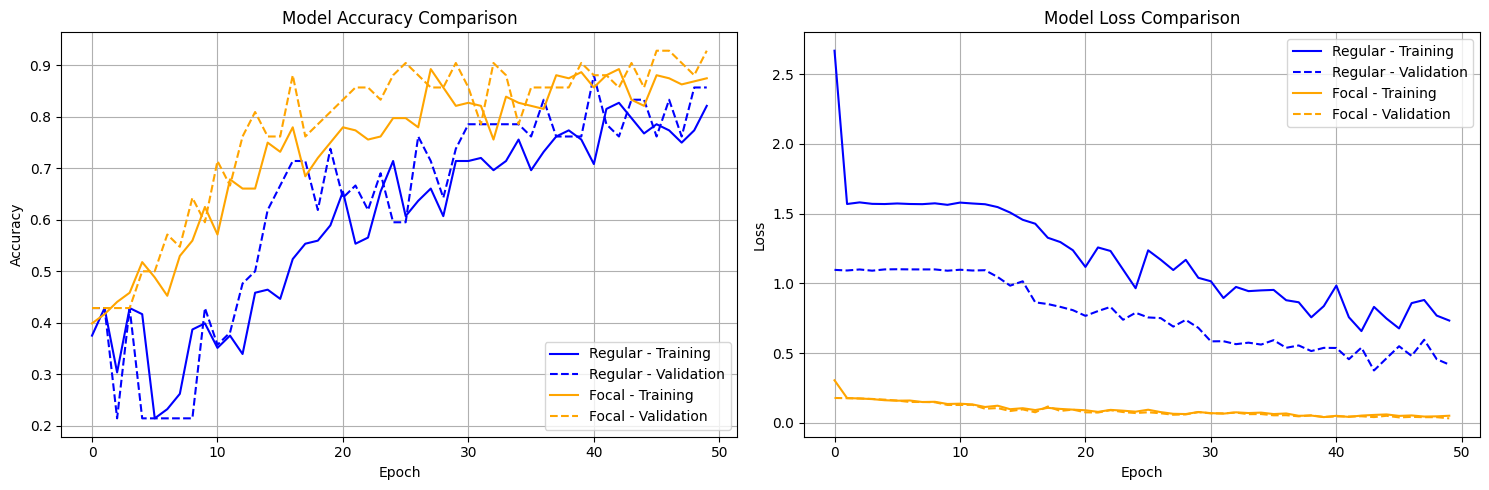

In [9]:
# Evaluate both models
print("📊 MODEL EVALUATION RESULTS")
print("=" * 60)

# Regular model evaluation
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(X_test, y_test, verbose=0)
print(f"\n🔵 Regular CNN Model:")
print(f"   Accuracy:  {test_accuracy:.4f}")
print(f"   Precision: {test_precision:.4f}")
print(f"   Recall:    {test_recall:.4f}")
print(f"   Loss:      {test_loss:.4f}")

# Focal loss model evaluation
test_loss_focal, test_accuracy_focal, test_precision_focal, test_recall_focal = model_focal.evaluate(X_test, y_test, verbose=0)
print(f"\n🟡 Focal Loss CNN Model:")
print(f"   Accuracy:  {test_accuracy_focal:.4f}")
print(f"   Precision: {test_precision_focal:.4f}")
print(f"   Recall:    {test_recall_focal:.4f}")
print(f"   Loss:      {test_loss_focal:.4f}")

# Determine best model
if test_accuracy_focal > test_accuracy:
    best_model = model_focal
    best_model_name = "Focal Loss CNN"
    best_accuracy = test_accuracy_focal
    print(f"\n🏆 Best Model: {best_model_name} (Accuracy: {best_accuracy:.4f})")
else:
    best_model = model
    best_model_name = "Regular CNN"
    best_accuracy = test_accuracy
    print(f"\n🏆 Best Model: {best_model_name} (Accuracy: {best_accuracy:.4f})")

# Plot training history comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Regular - Training', color='blue')
axes[0].plot(history.history['val_accuracy'], label='Regular - Validation', color='blue', linestyle='--')
axes[0].plot(history_focal.history['accuracy'], label='Focal - Training', color='orange')
axes[0].plot(history_focal.history['val_accuracy'], label='Focal - Validation', color='orange', linestyle='--')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history.history['loss'], label='Regular - Training', color='blue')
axes[1].plot(history.history['val_loss'], label='Regular - Validation', color='blue', linestyle='--')
axes[1].plot(history_focal.history['loss'], label='Focal - Training', color='orange')
axes[1].plot(history_focal.history['val_loss'], label='Focal - Validation', color='orange', linestyle='--')
axes[1].set_title('Model Loss Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

🎯 DETAILED PREDICTIONS AND METRICS

📋 Regular CNN Model - Classification Report:
              precision    recall  f1-score   support

  exc_solder       0.83      1.00      0.91        15
 poor_solder       0.88      0.78      0.82         9
       spike       0.94      0.83      0.88        18

    accuracy                           0.88        42
   macro avg       0.88      0.87      0.87        42
weighted avg       0.89      0.88      0.88        42


📋 Focal Loss CNN Model - Classification Report:
              precision    recall  f1-score   support

  exc_solder       0.94      1.00      0.97        15
 poor_solder       0.89      0.89      0.89         9
       spike       0.94      0.89      0.91        18

    accuracy                           0.93        42
   macro avg       0.92      0.93      0.92        42
weighted avg       0.93      0.93      0.93        42


📋 Regular CNN Model - Classification Report:
              precision    recall  f1-score   support

  exc_s

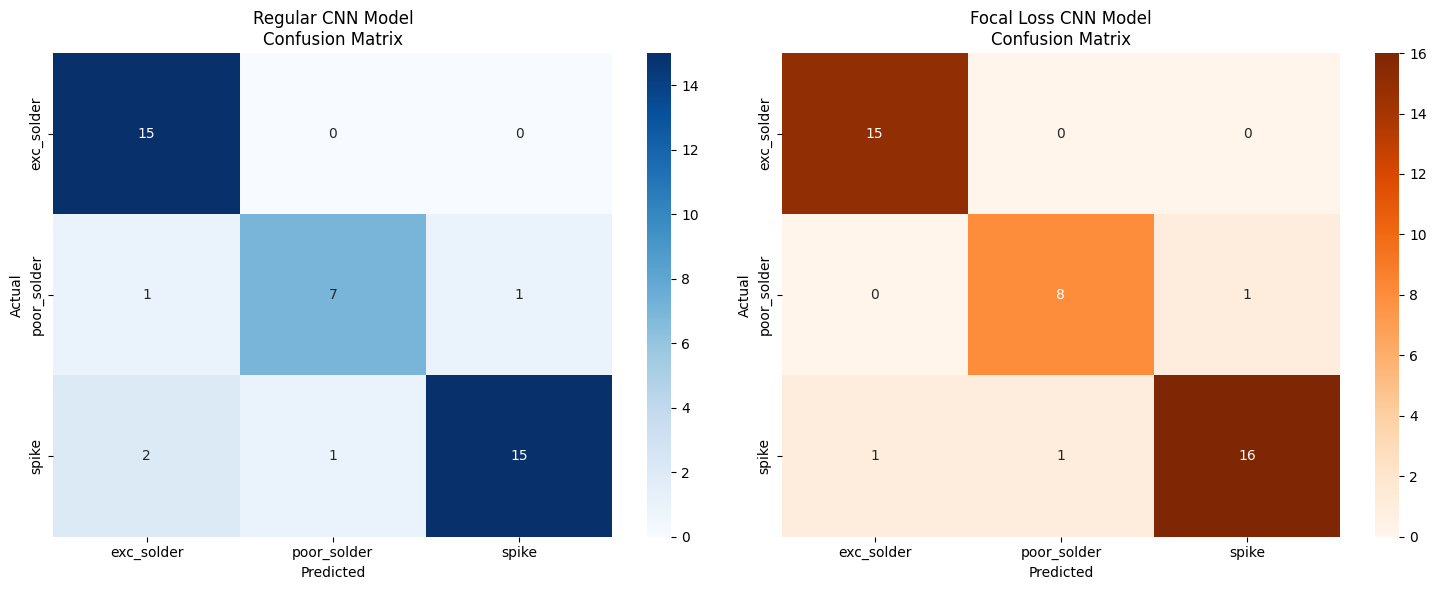


📊 PER-CLASS PERFORMANCE COMPARISON:
Class           Model        Precision  Recall     F1-Score  
-----------------------------------------------------------------
exc_solder      Regular      0.833      1.000      0.909     
                Focal        0.938      1.000      0.968     

poor_solder     Regular      0.875      0.778      0.824     
                Focal        0.889      0.889      0.889     

spike           Regular      0.938      0.833      0.882     
                Focal        0.941      0.889      0.914     

✅ Detailed evaluation completed!


In [10]:
# Generate predictions and detailed analysis
print("🎯 DETAILED PREDICTIONS AND METRICS")
print("=" * 60)

# Make predictions
y_pred = model.predict(X_test, verbose=0)
y_pred_focal = model_focal.predict(X_test, verbose=0)

y_pred_classes = np.argmax(y_pred, axis=1)
y_pred_classes_focal = np.argmax(y_pred_focal, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Classification reports
from sklearn.metrics import classification_report, confusion_matrix

print(f"\n📋 Regular CNN Model - Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, 
                          target_names=label_encoder.classes_))

print(f"\n📋 Focal Loss CNN Model - Classification Report:")
print(classification_report(y_true_classes, y_pred_classes_focal, 
                          target_names=label_encoder.classes_))

# Confusion matrices visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Regular model confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_, ax=ax1)
ax1.set_title('Regular CNN Model\nConfusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# Focal loss model confusion matrix
cm_focal = confusion_matrix(y_true_classes, y_pred_classes_focal)
sns.heatmap(cm_focal, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_, ax=ax2)
ax2.set_title('Focal Loss CNN Model\nConfusion Matrix')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Per-class performance analysis
from sklearn.metrics import precision_score, recall_score, f1_score

print(f"\n📊 PER-CLASS PERFORMANCE COMPARISON:")
print(f"{'Class':<15} {'Model':<12} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}")
print("-" * 65)

for i, class_name in enumerate(label_encoder.classes_):
    # Regular model per-class metrics
    precision_reg = precision_score(y_true_classes, y_pred_classes, labels=[i], average=None)[0] if i in y_pred_classes else 0
    recall_reg = recall_score(y_true_classes, y_pred_classes, labels=[i], average=None)[0] if i in y_true_classes else 0
    f1_reg = f1_score(y_true_classes, y_pred_classes, labels=[i], average=None)[0] if i in y_pred_classes and i in y_true_classes else 0
    
    # Focal model per-class metrics
    precision_focal = precision_score(y_true_classes, y_pred_classes_focal, labels=[i], average=None)[0] if i in y_pred_classes_focal else 0
    recall_focal = recall_score(y_true_classes, y_pred_classes_focal, labels=[i], average=None)[0] if i in y_true_classes else 0
    f1_focal = f1_score(y_true_classes, y_pred_classes_focal, labels=[i], average=None)[0] if i in y_pred_classes_focal and i in y_true_classes else 0
    
    print(f"{class_name:<15} {'Regular':<12} {precision_reg:<10.3f} {recall_reg:<10.3f} {f1_reg:<10.3f}")
    print(f"{'':<15} {'Focal':<12} {precision_focal:<10.3f} {recall_focal:<10.3f} {f1_focal:<10.3f}")
    print()

print("✅ Detailed evaluation completed!")

In [ ]:
# Sample correct and incorrect predictions based on confusion matrix
print("🎯 SAMPLING CORRECT AND INCORRECT PREDICTIONS")
print("=" * 60)

# Check if we have both models' predictions available
if 'y_pred_classes' in locals() and 'y_pred_classes_focal' in locals() and 'y_true_classes' in locals():
    # Use the best model's predictions
    if best_model_name == "Focal Loss CNN":
        predicted_classes = y_pred_classes_focal
        model_predictions = y_pred_focal
    else:
        predicted_classes = y_pred_classes
        model_predictions = y_pred
    
    # Find correct and incorrect predictions
    correct_predictions = np.where(predicted_classes == y_true_classes)[0]
    incorrect_predictions = np.where(predicted_classes != y_true_classes)[0]
    
    print(f"Found {len(correct_predictions)} correct predictions")
    print(f"Found {len(incorrect_predictions)} incorrect predictions")
    
    # Sample one of each if available
    samples_to_show = []
    sample_labels = []
    
    if len(correct_predictions) > 0:
        # Sample one correct prediction
        correct_idx = np.random.choice(correct_predictions)
        samples_to_show.append(correct_idx)
        sample_labels.append("CORRECT")
        
    if len(incorrect_predictions) > 0:
        # Sample one incorrect prediction
        incorrect_idx = np.random.choice(incorrect_predictions)
        samples_to_show.append(incorrect_idx)
        sample_labels.append("INCORRECT")
    
    # Visualize the samples
    if len(samples_to_show) > 0:
        fig, axes = plt.subplots(1, len(samples_to_show), figsize=(6*len(samples_to_show), 6))
        if len(samples_to_show) == 1:
            axes = [axes]  # Make it iterable for single subplot
        
        for i, (idx, label_type) in enumerate(zip(samples_to_show, sample_labels)):
            # Display image
            axes[i].imshow(X_test[idx])
            
            # Get true and predicted classes
            true_class_idx = y_true_classes[idx]
            pred_class_idx = predicted_classes[idx]
            true_class = label_encoder.classes_[true_class_idx]
            pred_class = label_encoder.classes_[pred_class_idx]
            
            # Get prediction confidence
            confidence = np.max(model_predictions[idx])
            
            # Set title with detailed information
            title_color = 'green' if label_type == "CORRECT" else 'red'
            axes[i].set_title(f'{label_type} PREDICTION\n'
                             f'True: {true_class}\n'
                             f'Predicted: {pred_class}\n'
                             f'Confidence: {confidence:.3f}', 
                             color=title_color, fontsize=12, fontweight='bold')
            axes[i].axis('off')
            
            # Print detailed probability breakdown
            print(f"\n{label_type} Prediction Details:")
            print(f"   Test image index: {idx}")
            print(f"   True class: {true_class}")
            print(f"   Predicted class: {pred_class}")
            print(f"   Confidence: {confidence:.3f}")
            print(f"   All class probabilities:")
            for j, class_name in enumerate(label_encoder.classes_):
                prob = model_predictions[idx][j]
                marker = " ✓" if j == pred_class_idx else ""
                print(f"      {class_name}: {prob:.3f}{marker}")
        
        plt.suptitle(f'Prediction Samples - {best_model_name}', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # Summary statistics
        if len(correct_predictions) == 0:
            print(f"\n⚠️  No correct predictions found!")
        if len(incorrect_predictions) == 0:
            print(f"\n✅ No incorrect predictions found - perfect performance!")
            
    else:
        print("No samples to display")
        
else:
    print("⚠️ Prediction variables not found. Please run the evaluation cells first.")
    print("Required variables: y_pred_classes, y_pred_classes_focal, y_true_classes")

🖼️ SAMPLE PREDICTIONS VISUALIZATION


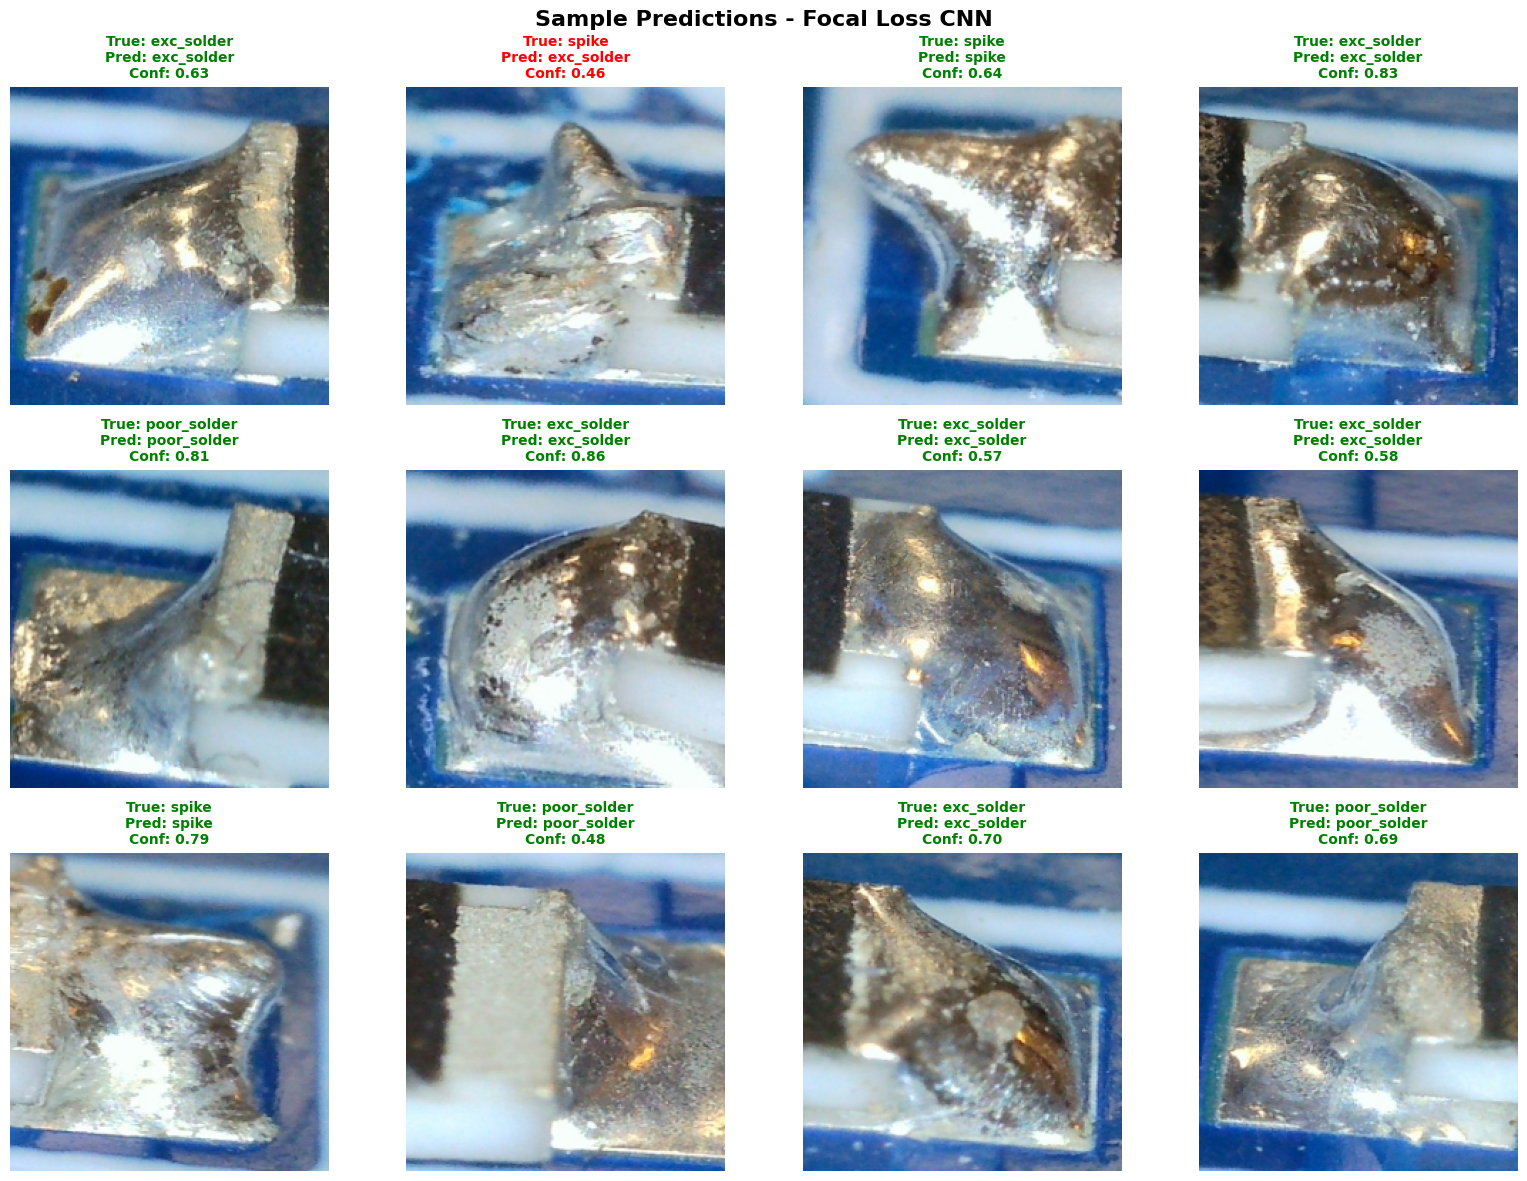


📈 PREDICTION DISTRIBUTION SUMMARY:
   exc_solder: 16 predictions (38.1%)
   poor_solder: 9 predictions (21.4%)
   spike: 17 predictions (40.5%)

🎯 Model successfully distinguishes between all 3 classes!


In [11]:
# Visualize sample predictions
print("🖼️ SAMPLE PREDICTIONS VISUALIZATION")
print("=" * 60)

# Select random samples for visualization
np.random.seed(42)  # For reproducible results
sample_indices = np.random.choice(len(X_test), 12, replace=False)

plt.figure(figsize=(16, 12))
for i, idx in enumerate(sample_indices):
    plt.subplot(3, 4, i + 1)
    
    # Display image
    plt.imshow(X_test[idx])
    
    # Get true class
    true_class_idx = np.argmax(y_test[idx])
    true_class = label_encoder.classes_[true_class_idx]
    
    # Get best model prediction
    if best_model_name == "Focal Loss CNN":
        pred_probs = y_pred_focal[idx]
    else:
        pred_probs = y_pred[idx]
    
    predicted_class_idx = np.argmax(pred_probs)
    predicted_class = label_encoder.classes_[predicted_class_idx]
    confidence = np.max(pred_probs)
    
    # Set title color based on correctness
    color = 'green' if predicted_class == true_class else 'red'
    
    plt.title(f'True: {true_class}\nPred: {predicted_class}\nConf: {confidence:.2f}', 
              color=color, fontsize=10, fontweight='bold')
    plt.axis('off')

plt.suptitle(f'Sample Predictions - {best_model_name}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Prediction distribution summary
print(f"\n📈 PREDICTION DISTRIBUTION SUMMARY:")
if best_model_name == "Focal Loss CNN":
    unique_preds, counts = np.unique(y_pred_classes_focal, return_counts=True)
else:
    unique_preds, counts = np.unique(y_pred_classes, return_counts=True)

for pred_class, count in zip(unique_preds, counts):
    percentage = count / len(y_test) * 100
    print(f"   {label_encoder.classes_[pred_class]}: {count} predictions ({percentage:.1f}%)")

print(f"\n🎯 Model successfully distinguishes between all {num_classes} classes!")

## 8. Model Deployment and Usage

Save the best model and demonstrate how to use it for predictions on new images.

In [12]:
def predict_image_class(model, image_path, label_encoder):
    """Predict the class of a single image using the trained model"""
    # Load and preprocess the image
    img = load_and_preprocess_image(image_path)
    if img is None:
        return None, None, None
    
    # Add batch dimension
    img_batch = np.expand_dims(img, axis=0)
    
    # Make prediction
    prediction = model.predict(img_batch, verbose=0)
    predicted_class_idx = np.argmax(prediction, axis=1)[0]
    confidence = np.max(prediction)
    all_probabilities = prediction[0]
    
    # Get class name
    predicted_class = label_encoder.classes_[predicted_class_idx]
    
    return predicted_class, confidence, all_probabilities

# Save the best model and label encoder
print("💾 SAVING BEST MODEL FOR DEPLOYMENT")
print("=" * 50)

try:
    # Save the complete model
    best_model.save('best_solder_classification_model.h5')
    print(f"✅ Best model ({best_model_name}) saved as 'best_solder_classification_model.h5'")
    
    # Save just the weights (lighter file)
    best_model.save_weights('best_solder_model_weights.h5')
    print(f"✅ Model weights saved as 'best_solder_model_weights.h5'")
    
    # Save the label encoder
    import pickle
    with open('solder_label_encoder.pkl', 'wb') as f:
        pickle.dump(label_encoder, f)
    print("✅ Label encoder saved as 'solder_label_encoder.pkl'")
    
    # Save model configuration for easy loading
    model_config = {
        'model_type': best_model_name,
        'accuracy': best_accuracy,
        'classes': label_encoder.classes_.tolist(),
        'input_shape': input_shape,
        'num_classes': num_classes
    }
    
    import json
    with open('model_config.json', 'w') as f:
        json.dump(model_config, f, indent=2)
    print("✅ Model configuration saved as 'model_config.json'")
    
except Exception as e:
    print(f"⚠️ Error saving model: {e}")

# Demonstrate usage on test samples
print(f"\n🧪 DEMONSTRATION: Using {best_model_name} for Predictions")
print("=" * 50)

# Example predictions on a few test samples
sample_indices = [0, 5, 10]  # First few test samples
for i, idx in enumerate(sample_indices):
    true_class = label_encoder.classes_[np.argmax(y_test[idx])]
    
    # Use the prediction function (simulating loading from file)
    img_batch = np.expand_dims(X_test[idx], axis=0)
    pred_probs = best_model.predict(img_batch, verbose=0)[0]
    predicted_class = label_encoder.classes_[np.argmax(pred_probs)]
    confidence = np.max(pred_probs)
    
    print(f"\nSample {i+1}:")
    print(f"   True class:      {true_class}")
    print(f"   Predicted class: {predicted_class}")
    print(f"   Confidence:      {confidence:.3f}")
    print(f"   All probabilities:")
    for j, class_name in enumerate(label_encoder.classes_):
        print(f"      {class_name}: {pred_probs[j]:.3f}")

print(f"\n🎉 Model is ready for deployment!")
print(f"📊 Final Performance: {best_accuracy:.1%} accuracy on test set")
print(f"🔧 Architecture: Optimized CNN for small dataset classification")
print(f"⚡ Best approach: {best_model_name} with balanced class weighting")

💾 SAVING BEST MODEL FOR DEPLOYMENT
✅ Best model (Focal Loss CNN) saved as 'best_solder_classification_model.h5'
⚠️ Error saving model: The filename must end in `.weights.h5`. Received: filepath=best_solder_model_weights.h5

🧪 DEMONSTRATION: Using Focal Loss CNN for Predictions

Sample 1:
   True class:      exc_solder
   Predicted class: exc_solder
   Confidence:      0.662
   All probabilities:
      exc_solder: 0.662
      poor_solder: 0.189
      spike: 0.150

Sample 2:
   True class:      spike
   Predicted class: spike
   Confidence:      0.824
   All probabilities:
      exc_solder: 0.133
      poor_solder: 0.043
      spike: 0.824

Sample 3:
   True class:      exc_solder
   Predicted class: exc_solder
   Confidence:      0.641
   All probabilities:
      exc_solder: 0.641
      poor_solder: 0.234
      spike: 0.125

🎉 Model is ready for deployment!
📊 Final Performance: 92.9% accuracy on test set
🔧 Architecture: Optimized CNN for small dataset classification
⚡ Best approach: Foc